Project Title: Sales Data Analysis

Objective:
To analyze sales data and identify trends, patterns, and business insights.

Tools Used:
Python, Pandas, Matplotlib

Dataset:
Retail sales dataset containing orders, customers, and product details.

#**Imports**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#**Reading** **File**

In [8]:
df=pd.read_csv('train.csv',index_col=False)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


#**Data** **Cleaning**

In [21]:
#check null
n=df.isnull().sum()
print(n)


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Shipping Days    0
Month            0
Year             0
dtype: int64


In [10]:
#Filling null with zero
df['Postal Code'] = df['Postal Code'].fillna(0)

In [11]:
#check duplicate
d=df.duplicated().sum()
print(d)

0


In [12]:
#Converting dates column from string to dates
df["Order Date"]=pd.to_datetime(df["Order Date"],dayfirst=True)
df["Ship Date"]=pd.to_datetime(df["Ship Date"],dayfirst=True)

#**Data** **Transformation**

In [13]:
#Creating Shipping Days
df["Shipping Days"]=df["Ship Date"]-df["Order Date"]


In [14]:
#Extracting month and year from order date column
df["Month"]=df["Order Date"].dt.month
df["Year"]=df["Order Date"].dt.year

In [15]:
#Total Sales
total_sales=df["Sales"].sum
print(total_sales)

<bound method Series.sum of 0       261.9600
1       731.9400
2        14.6200
3       957.5775
4        22.3680
          ...   
9795      3.7980
9796     10.3680
9797    235.1880
9798     26.3760
9799     10.3840
Name: Sales, Length: 9800, dtype: float64>


In [16]:
#Sales by Region
region_sales=df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


In [17]:
#Sales by Category
category_sales=df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [18]:
#Monthly Sales
monthly_sales=df.groupby("Month")["Sales"].sum()
print(monthly_sales)

Month
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


In [19]:
#Top Customers
top_customers=df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


#**Data** **Visualization**


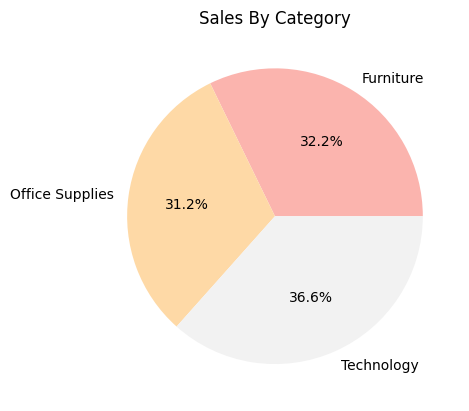

Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


In [35]:
from enum import auto
category_sales.plot(kind="pie",autopct="%1.1f%%", colormap='Pastel1')

plt.title("Sales By Category")
plt.ylabel("")
plt.show()
print(category_sales)

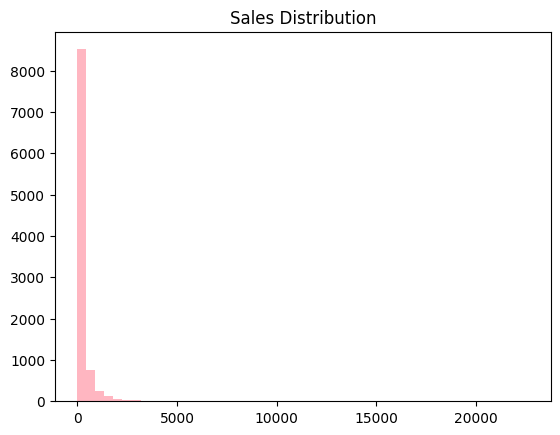

In [44]:
plt.hist(df["Sales"],bins=50,color="#FFB6C1")
plt.title("Sales Distribution")
plt.show()

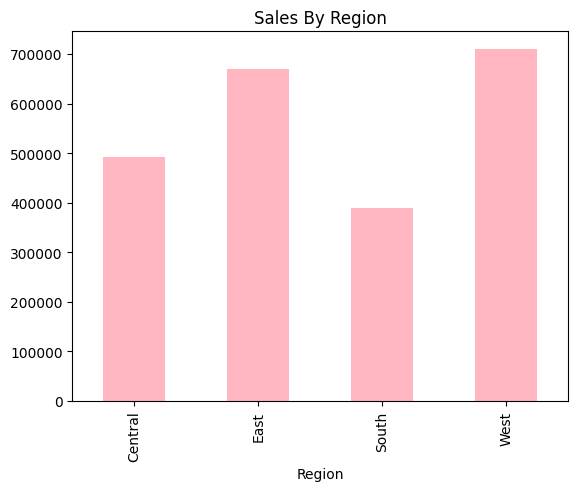

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


In [46]:
region_sales.plot(kind="bar",color="#FFB6C1")
plt.title("Sales By Region")
plt.show()
print(region_sales)

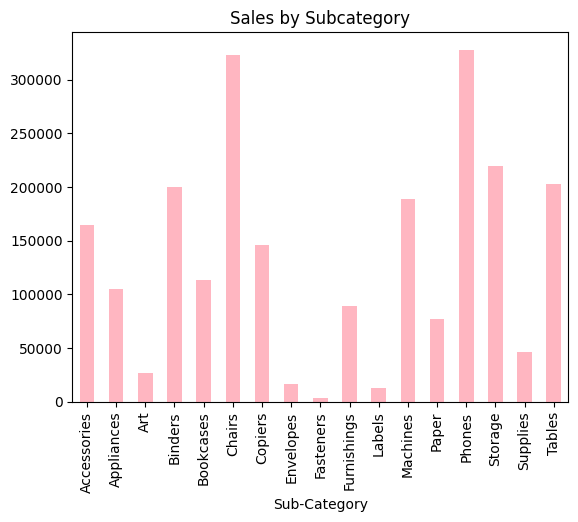

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Chairs         322822.7310
Copiers        146248.0940
Envelopes       16128.0460
Fasteners        3001.9600
Furnishings     89212.0180
Labels          12347.7260
Machines       189238.6310
Paper           76828.3040
Phones         327782.4480
Storage        219343.3920
Supplies        46420.3080
Tables         202810.6280
Name: Sales, dtype: float64


In [47]:
subcat_sales=df.groupby("Sub-Category")["Sales"].sum()

subcat_sales.plot(kind="bar",color="#FFB6C1")
plt.title("Sales by Subcategory")
plt.show()
print(subcat_sales)

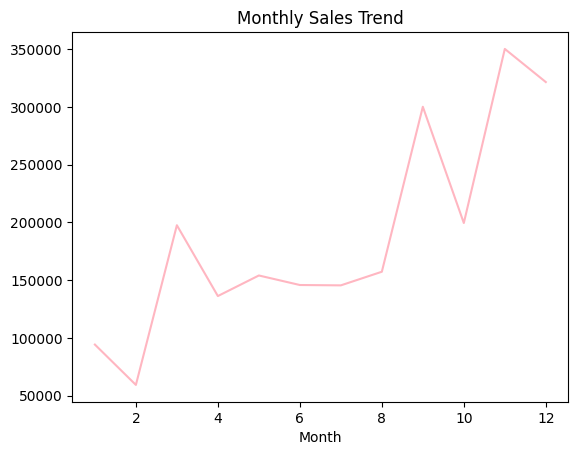

In [48]:

monthly_sales.plot(color="#FFB6C1")
plt.title("Monthly Sales Trend")
plt.show()

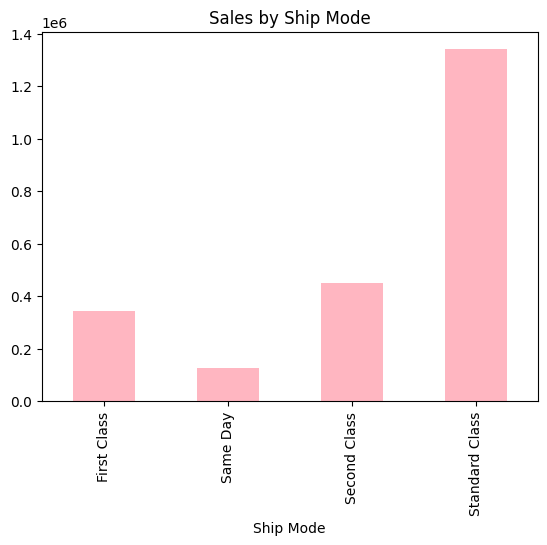

Ship Mode
First Class         345,572
Same Day            125,219
Second Class        449,914
Standard Class    1,340,831
Name: Sales, dtype: object


In [49]:
ship_mode_sale=df.groupby("Ship Mode")["Sales"].sum()
ship_mode_sale.plot(kind="bar",color="#FFB6C1")
plt.title("Sales by Ship Mode")
plt.show()
print(ship_mode_sale.apply(lambda x: f"{x:,.0f}"))

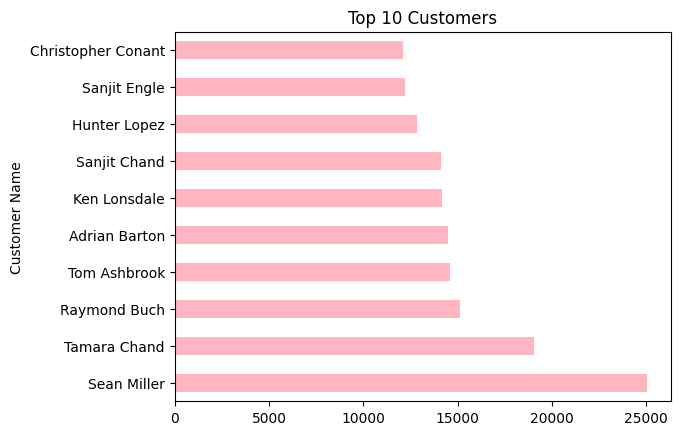

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


In [50]:
top_customers.plot(kind="barh",color="#FFB6C1")
plt.title("Top 10 Customers")
plt.show()
print(top_customers)

#**Insights**

###Insight 1: West region contributes the highest sales among all regions.






###Insight 2: Central and South regions show comparatively lower sales performance.

###Insight 3: Technology category generates the highest revenue.

###Insight 4: Furniture category has lower sales compared to Technology and Office Supplies.

###Insight 5: Certain sub-categories contribute disproportionately to total sales.

###Insight 6: A few sub-categories dominate revenue while others underperform.

###Insight 7: Standard Class contributes the highest sales.

###Insight 8: Same Day shipping has the lowest sales contribution.

###Insight 9: Sales show variation across months, indicating seasonal trends.

###Insight 10: Certain months have peak sales which can be targeted for promotions.

###Insight 11: A small group of customers contributes significantly to total sales.

###Insight 12: Top 10 customers generate a large portion of revenue.